In [3]:
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as no
from tensorflow import keras

In [4]:
(X_train , y_train) , (X_test , y_test) = keras.datasets.mnist.load_data()

In [5]:
len(X_train)

60000

In [6]:
len(X_test)

10000

In [8]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

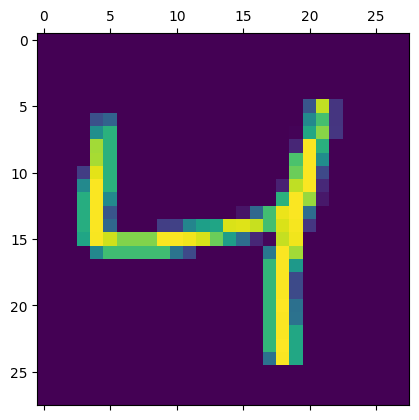

In [9]:
plt.matshow(X_train[2])

In [11]:
y_train[2]

np.uint8(4)

### Convert into 1d array

In [14]:
X_train.shape

(60000, 28, 28)

In [33]:
X_train = X_train /255 ## Scaling
X_test = X_test /255

In [28]:
X_train_flattened = X_train.reshape(len(X_train),28*28)

In [29]:
X_train_flattened.shape

(60000, 784)

In [30]:
X_test.shape

(10000, 28, 28)

In [31]:
X_test_flattened = X_test.reshape(len(X_test),28*28)
X_test_flattened.shape

(10000, 784)

# Simple NN with two layers

In [32]:
model = keras.Sequential([
    keras.layers.Dense(
        10,
        input_shape=(784,),
        activation='sigmoid'
    )
])  # neurons in one layer connected to output layer

# 10 outputs representing digits 0–9

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train_flattened, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 342us/step - accuracy: 0.8769 - loss: 0.4709
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 348us/step - accuracy: 0.9159 - loss: 0.3035
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 346us/step - accuracy: 0.9207 - loss: 0.2832
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 363us/step - accuracy: 0.9241 - loss: 0.2734
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 349us/step - accuracy: 0.9259 - loss: 0.2666


In [34]:
model.evaluate(X_test_flattened , y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 363us/step - accuracy: 0.9247 - loss: 0.2696


[0.2695809006690979, 0.9247000217437744]

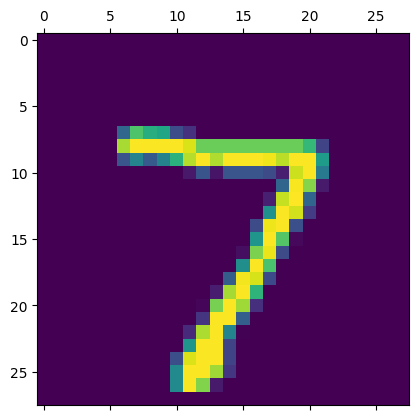

In [36]:
plt.matshow(X_test[0])

In [38]:
y_pred = model.predict(X_test_flattened)
y_pred[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 250us/step


array([3.75433490e-02, 4.53632538e-07, 6.06654398e-02, 9.59946930e-01,
       2.19763815e-03, 1.26476645e-01, 1.83723046e-06, 9.99764025e-01,
       1.02591395e-01, 6.38276041e-01], dtype=float32)

In [40]:
import numpy as np

In [41]:
np.argmax(y_pred[0])

np.int64(7)